In [1]:
pip install plotly

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import plotly.express as px
import pandas as pd

In [3]:
countries_path = r'C:\Users\titas\Desktop\LP_Project\Warehouse Optimisation\data\warehouses.csv'

In [4]:
df = pd.read_csv(countries_path)
df

,id,name,latitude,longitude,capacity
0,W1,Basildon Distribution Centre,51.588740,0.485961,5000
1,W2,Birmingham Distribution Centre,52.514284,-1.880850,6000
2,W3,Leeds Distribution Centre,53.772075,-1.514109,4000


In [17]:
# convert long/lat to points
df_geo = gpd.GeoDataFrame(df, geometry = gpd.points_from_xy(df.longitude, df.latitude))
df_geo

,id,name,latitude,longitude,capacity,geometry
0,W1,Basildon Distribution Centre,51.588740,0.485961,5000,POINT (0.48596 51.58874)
1,W2,Birmingham Distribution Centre,52.514284,-1.880850,6000,POINT (-1.88085 52.51428)
2,W3,Leeds Distribution Centre,53.772075,-1.514109,4000,POINT (-1.51411 53.77208)


In [21]:
%pip install geodatasets
import geodatasets

# get built-in dataset
world_data = gpd.read_file(geodatasets.get_path('naturalearth.land'))
world_data

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip available: 22.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


     ---------------------------------------- 67.2/67.2 kB ? eta 0:00:00
     ---------------------------------------- 73.1/73.1 kB 3.9 MB/s eta 0:00:00
     ------------------------------------- 206.7/206.7 kB 12.3 MB/s eta 0:00:00
     ---------------------------------------- 68.5/68.5 kB 3.6 MB/s eta 0:00:00
     ---------------------------------------- 131.1/131.1 kB ? eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


,featurecla,scalerank,min_zoom,geometry
0,Land,1,1.0,"POLYGON ((-59.57209 -80.04018, -59.86585 -80.5..."
1,Land,1,1.0,"POLYGON ((-159.20818 -79.49706, -161.1276 -79...."
2,Land,1,0.0,"POLYGON ((-45.15476 -78.04707, -43.92083 -78.4..."
3,Land,1,1.0,"POLYGON ((-121.21151 -73.50099, -119.91885 -73..."
4,Land,1,1.0,"POLYGON ((-125.55957 -73.48135, -124.03188 -73..."
...,...,...,...,...
122,Land,1,1.0,"POLYGON ((51.13619 80.54728, 49.79368 80.41543..."
123,Land,0,0.0,"POLYGON ((99.93976 78.88094, 97.75794 78.7562,..."
124,Land,0,0.0,"POLYGON ((-87.02 79.66, -85.81435 79.3369, -87..."
125,Land,0,0.0,"POLYGON ((-68.5 83.10632, -65.82735 83.02801, ..."


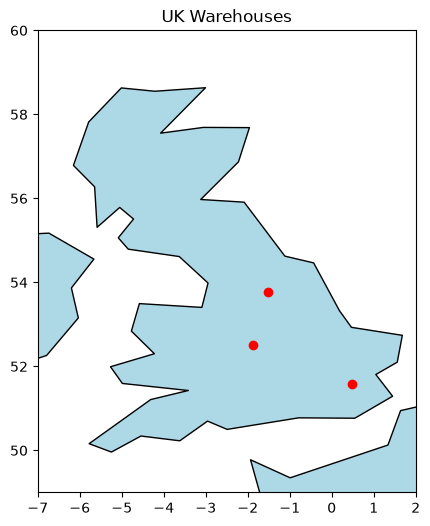

In [38]:
# plot the world map
axis = world_data.plot(color='lightblue', edgecolor='black')
df_geo.plot(ax=axis, color='red')

# Zoom the map view exclusively to the UK coordinates
axis.set_xlim(-7, 2)   # Longitude (West to East)
axis.set_ylim(49, 60)   # Latitude (South to North)

plt.title('UK Warehouses')

fig = plt.gcf()
fig.set_size_inches(9,6)
fig.savefig('matplot.png', dpi = 200)
plt.show()

In [5]:
import plotly.express as px

f = px.scatter_geo(
    df,
    lat="latitude",
    lon="longitude",
    hover_name="name",
    size="capacity",
    scope="europe",
    title="UK Warehouses",
    projection="natural earth",
    template="plotly_white"
 )

f.update_geos(
    lonaxis_range=[-8, 2],
    lataxis_range=[49, 59],
    showcountries=True
)

f